In [13]:
%pip install numpy
%pip install matplotlib
%pip install imageio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from __future__ import annotations
from helpers.env import SlipperyGridWorld, ACTIONS
from helpers.viz import evaluate, plot_policy, plot_value_heatmap, run_to_gif
from helpers.viz import greedy_policy_from_V
import numpy as np
import matplotlib.pyplot as plt

In [15]:
# Available actions
# Action mapping: 0=Up, 1=Right, 2=Down, 3=Left
print(ACTIONS)



(0, 1, 2, 3)


In [16]:
# =============================CONFIGURATION BLOCK============================= #
# |                   Change the parameters and see what happens              | #
# =============================CONFIGURATION BLOCK============================= #

# Example parameters set up for environment
num_rows = 5
num_cols = 7
start_state = (0, 0)
goal_state = (4, 6)
slip_prob = 0.2
random_seed = 987
step_reward = -1e5
goal_reward = 10

# VI parameters
max_number_iterations = 100 # max number of value iterations
threshold = 1e-5 # stopping condition
gamma = 0.99 # discount factor

# Evaluation parameters
max_steps_in_env = 20 # used for episodic evaluation


In [17]:
# Note that states have both (row, column) and row*num_cols + column representations
# i.e., tuple(int, int) or int, see functions docstrings for details
env = SlipperyGridWorld(rows=num_rows, cols=num_cols, start=start_state, goal=goal_state,
                        step_reward=step_reward, goal_reward=goal_reward,
                        slip_prob=slip_prob, max_steps=max_steps_in_env, seed=random_seed)
s = env.reset() # prepared clean environment

num_states = num_rows * num_cols # number of unique states
V  = np.zeros(num_states) # initialization for V(s)

# put your VI implementation here
# hint: environment has env.get_transition_distribution, env.is_terminal_state and env.reward functions to aid you
# try looking at these functions' docs for inspiration



# ----------------------------- VALUE ITERATION ----------------------------- #
# Bellman optimality update:
# V_{k+1}(s) = max_a sum_{s'} p(s'|s,a) [ r(s,a,s') + gamma * V_k(s') ]

for iteration in range(max_number_iterations):
    delta = 0.0
    V_new = V.copy()

    for state in range(num_states):
        if env.is_terminal_state(state):
            continue

        old_value = V[state]
        q_values = []

        for action in ACTIONS:
            q_sa = 0.0

            for prob, next_state in env.get_transition_distribution(state, action):
                reward = env.reward(state, action, next_state)

                if env.is_terminal_state(next_state):
                    q_sa += prob * reward
                else:
                    q_sa += prob * (reward + gamma * V[next_state])

            q_values.append(q_sa)

        V_new[state] = max(q_values)
        delta = max(delta, abs(old_value - V_new[state]))

    V = V_new

    if delta < threshold:
        print(f"Value Iteration converged after {iteration + 1} iterations.")
        break
else:
    print(f"Stopped after reaching max_number_iterations = {max_number_iterations}.")

Value Iteration converged after 50 iterations.


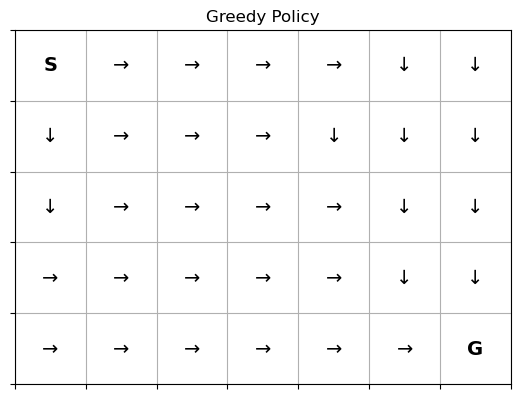

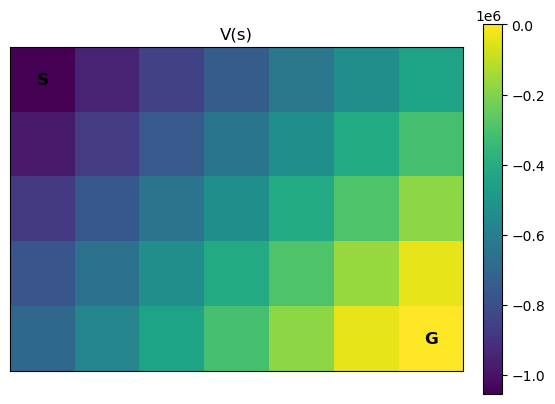

{'avg_return': -1091990.0, 'std_return': 192707.0315, 'success_rate': 1.0, 'avg_steps': 11.92}


ValueError: all input arrays must have the same shape

In [18]:
policy_plot_name = "policy_VI.png"
value_plot_name = "value_VI.png"
gif_name = "episode_VI.gif"
n_val_episodes = 50

env.reset()

# retrieve policy from V(s)
pi = greedy_policy_from_V(V, env, gamma)

# visualize policy and V(s)
plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy")
plot_value_heatmap(env, V, filename=value_plot_name, title="V(s)")
plt.close("all")

# evaluate deterministic policy over multiple episodes 
metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print(metrics)

# save one episode to gif
run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)